# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.

To meet the requirements for this project, you will need to achieve an accuracy greater than 45%. 
If you want to beat Detectocorp's algorithm, you'll need to achieve an accuracy greater than 70%. 
(Beating Detectocorp's algorithm is not a requirement for passing this project, but you're encouraged to try!)

Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [6]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html#torchvision.datasets.CIFAR10)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [7]:
# Define transforms
## YOUR CODE HERE ##
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Data Augmentatio
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Create training set and define training dataloader
trainset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)

# Create test set and define test dataloader
testset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = DataLoader(
    testset,
    batch_size=32,
    shuffle=False
)

# The 10 classes in the dataset
classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)
# Create training set and define training dataloader
## YOUR CODE HERE ##

# Create test set and define test dataloader
## YOUR CODE HERE ##

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [8]:
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
    
        image = images[i].numpy()
        plt.imshow(np.rot90(image.T, k=3))
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Training samples: 50000
Test samples: 10000
Image batch shape: torch.Size([32, 3, 32, 32])
Label batch shape: torch.Size([32])
dog


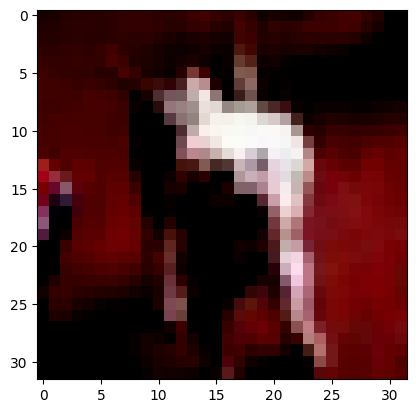

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


deer


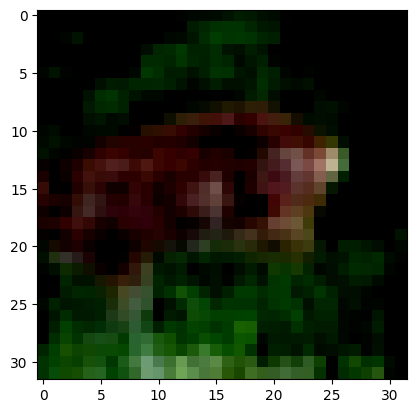

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


car


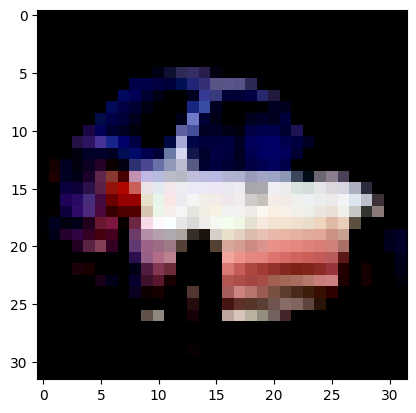

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


deer


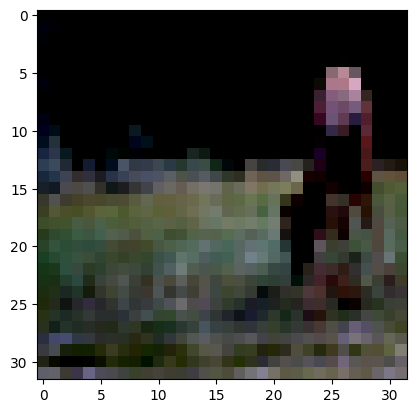

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


dog


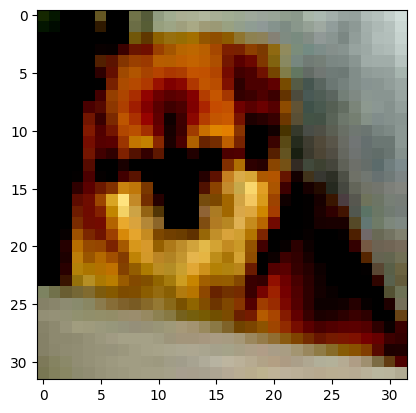

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


cat


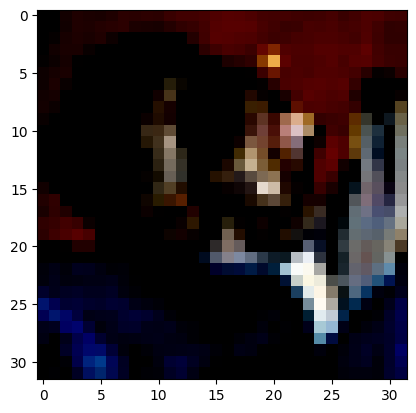

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


ship


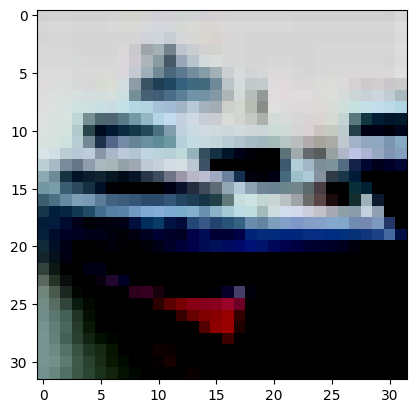

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


ship


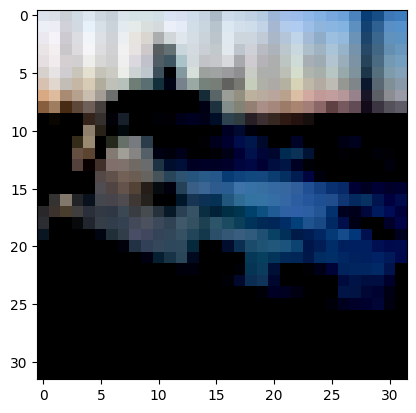

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


plane


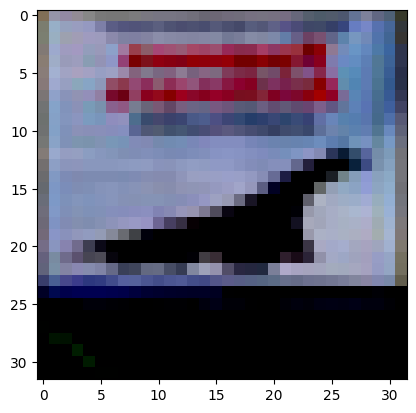

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


frog


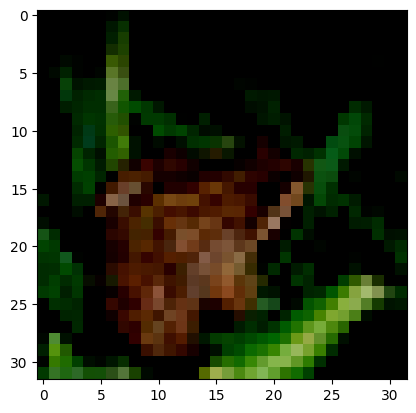

In [9]:
# Explore data
## YOUR CODE HERE ##

print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")

images, labels = next(iter(trainloader))

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

show5(trainloader)
show5(testloader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [10]:
## YOUR CODE HERE ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Build neural network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Input: 3 x 32 x 32
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        # After 3 pool layers:
        # 32x32 -> 16x16 -> 8x8 -> 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32 x 16 x 16
        x = self.pool(F.relu(self.conv2(x)))   # 64 x 8 x 8
        x = self.pool(F.relu(self.conv3(x)))   # 128 x 4 x 4

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return F.log_softmax(x, dim=1)



Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [11]:
## YOUR CODE HERE ##
# Instantiate model
model = Net()

# CrossEntropyLoss is standard for multi-class classification.
# It expects raw class scores from the model, not softmax probabilities.
criterion = nn.NLLLoss()

# Adam is a good default optimizer for this kind of project.
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [12]:
## YOUR CODE HERE ##
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

epochs = 10

train_losses = []

for epoch in range(epochs):

    running_loss = 0.0

    model.train()

    for batch_idx, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 250 == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}], "
                f"Batch [{batch_idx+1}/{len(trainloader)}], "
                f"Loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / len(trainloader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Average Loss: {epoch_loss:.4f}"
    )

Epoch [1/10], Batch [250/1563], Loss: 1.6073
Epoch [1/10], Batch [500/1563], Loss: 1.5774
Epoch [1/10], Batch [750/1563], Loss: 1.4939
Epoch [1/10], Batch [1000/1563], Loss: 0.9611
Epoch [1/10], Batch [1250/1563], Loss: 1.0823
Epoch [1/10], Batch [1500/1563], Loss: 1.1068
Epoch 1/10 Average Loss: 1.3995
Epoch [2/10], Batch [250/1563], Loss: 1.1952
Epoch [2/10], Batch [500/1563], Loss: 1.1205
Epoch [2/10], Batch [750/1563], Loss: 0.8343
Epoch [2/10], Batch [1000/1563], Loss: 0.9347
Epoch [2/10], Batch [1250/1563], Loss: 1.0062
Epoch [2/10], Batch [1500/1563], Loss: 0.7037
Epoch 2/10 Average Loss: 0.9871
Epoch [3/10], Batch [250/1563], Loss: 0.8412
Epoch [3/10], Batch [500/1563], Loss: 0.6959
Epoch [3/10], Batch [750/1563], Loss: 0.9084
Epoch [3/10], Batch [1000/1563], Loss: 1.0003
Epoch [3/10], Batch [1250/1563], Loss: 0.7959
Epoch [3/10], Batch [1500/1563], Loss: 1.1645
Epoch 3/10 Average Loss: 0.8170
Epoch [4/10], Batch [250/1563], Loss: 0.8241
Epoch [4/10], Batch [500/1563], Loss: 0.

Plot the training loss (and validation loss/accuracy, if recorded).

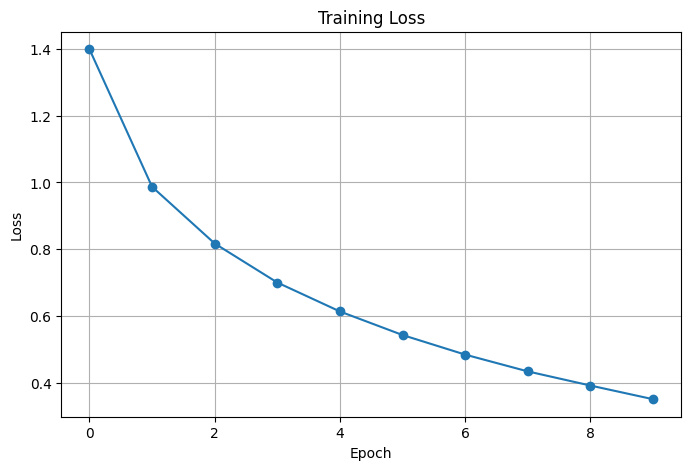

In [13]:
## YOUR CODE HERE ##
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [14]:
## YOUR CODE HERE ##
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Highest scoring class = prediction
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 75.54%


## Saving your model
Using `torch.save`, save your model for future loading.

In [15]:
## YOUR CODE HERE ##
torch.save(model.state_dict(), "cifar10_model.pth")

## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.

Some things to consider as you formulate your recommendation:
* How does your model compare to Detectocorp's model?
* How does it compare to the far more advanced solutions in the literature? 
* What did you do to get the accuracy you achieved? 
* Is it necessary to improve this accuracy? If so, what sort of work would be involved in improving it?


Based on the evaluation, I recommend building the model in-house rather than buying Detectocorp's model. My model achieved a test accuracy of 75.54%, which is higher than Detectocorp's reported 70% accuracy. This suggests that a relatively simple convolutional neural network can outperform the external option while remaining understandable and customizable.

The model does not match the much more advanced results reported in the literature, where some models achieve over 90% accuracy. However, those systems are much larger, more complex, and more expensive to train. For this project, the goal is not to produce a state-of-the-art CIFAR-10 classifier, but to determine whether an effective internal model is feasible.

To reach this accuracy, I used a convolutional neural network suitable for image classification, with convolutional layers, ReLU activations, max pooling, dropout, the CrossEntropyLoss function, and the Adam optimizer. This architecture allowed the model to learn visual features from the CIFAR-10 images while reducing overfitting.

Further improvement is possible, but may not be necessary unless the business problem requires significantly higher accuracy. Improving the model would likely involve more training, stronger data augmentation, hyperparameter tuning, batch normalization, deeper CNN architectures, or using transfer learning / more advanced architectures. These changes would require additional development and compute resources. Given that the current model already exceeds Detectocorp's benchmark, I recommend building the model internally for this use case.



## Submit Your Project

When you are finished editing the notebook and are ready to turn it in, simply click the **SUBMIT PROJECT** button in the lower right.

Once you submit your project, we'll review your work and give you feedback if there's anything that you need to work on. If you'd like to see the exact points that your reviewer will check for when looking at your work, you can have a look over the project [rubric](https://review.udacity.com/#!/rubrics/3077/view).